In [69]:
import math

from common import *
from experiment import *
from data import RawData, PlottableData

In [70]:
def TREATMENTS(protocol, prefix):
    return [
        Treatment(protocol, label=f'{prefix}', network_options=['--network-statistics'], protocol_options=[]),
        # Treatment(protocol, label=f'{prefix}_bridge', network_options=['--network-statistics', '--proxy', 'bridge'], protocol_options=[]),
        # Treatment(protocol, label=f'{prefix}_quacker', network_options=['--network-statistics', '--proxy', 'bridge', '--quacker',], protocol_options=[]),
        Treatment(protocol, label=f'{prefix}_sidekick_delay0ms', network_options=['--network-statistics', '--proxy', 'sidekick', '--quacker'], protocol_options=[]),
        Treatment(protocol, label=f'{prefix}_sidekick_delay60ms', network_options=['--network-statistics', '--proxy', 'sidekick', '--quacker'], protocol_options=['--ack-delay', '60']),
        Treatment(protocol, label=f'{prefix}_sidekick_delay110ms', network_options=['--network-statistics', '--proxy', 'sidekick', '--quacker'], protocol_options=['--ack-delay', '110']),
        # Treatment(protocol, label=f'{prefix}_sidekick_delay165ms', network_options=['--network-statistics', '--proxy', 'sidekick', '--quacker'], protocol_options=['--ack-delay', '165']),
        # Treatment(protocol, label=f'{prefix}_sidekick_delay220ms', network_options=['--network-statistics', '--proxy', 'sidekick', '--quacker'], protocol_options=['--ack-delay', '220']),
        # Treatment('tcp', label=f'tcp_pep', network_options=['--network-statistics', '--proxy', 'pepsal'], protocol_options=[]),
    ]

LOSS1_VALUES = [0, '0.25', '0.5', 1, '1.5', 2, '2.5', 3, '3.5', 4, 5, 6, 7, 8]
LOSS1_VALUES = [0, 1, 2, 3, 4, 5, 6, 7, 8]
def NETWORK_SETTINGS(loss_values=LOSS1_VALUES, n=len(LOSS1_VALUES)):
    return [
        NetworkSetting(bw1=50, bw2=10, delay1=1, delay2=100, loss1=loss1, loss2=0)
        for loss1 in LOSS1_VALUES[:n]
    ]

DATA_SIZES = [12500000]

# Collect data for experiments

In [ ]:
# NOTE: We have to run one trial at a time with the sidekick since it can only handle one connection at a time,
# and it decides which connection to handle by the first UDP packet it observes
for i in range(1, 10):
    exp = Experiment(num_trials=i, treatments=TREATMENTS('picoquic', 'quic'), network_settings=NETWORK_SETTINGS(), data_sizes=DATA_SIZES)
    picoquic_raw_data = RawData(exp, execute=True)

18
57.14697599411011mulation/main.py --bw1 50 --delay2 100 --loss1 6 --loss2 0 -t 1 --label quic --network-statistics picoquic -n 12500000 
sudo -E python3 emulation/main.py --bw1 50 --delay2 100 --loss1 7 --loss2 0 -t 1 --label quic --network-statistics picoquic -n 12500000 

In [64]:
exp = Experiment(num_trials=10, treatments=TREATMENTS('picoquic', 'quic'), network_settings=NETWORK_SETTINGS(), data_sizes=DATA_SIZES)
picoquic_raw_data = RawData(exp, execute=False)

MISSING: sudo -E python3 emulation/main.py --bw1 50 --delay2 100 --loss1 0 --loss2 0 -t 9 --label quic --network-statistics picoquic -n 12500000
MISSING: sudo -E python3 emulation/main.py --bw1 50 --delay2 100 --loss1 1 --loss2 0 -t 9 --label quic --network-statistics picoquic -n 12500000
MISSING: sudo -E python3 emulation/main.py --bw1 50 --delay2 100 --loss1 2 --loss2 0 -t 9 --label quic --network-statistics picoquic -n 12500000
MISSING: sudo -E python3 emulation/main.py --bw1 50 --delay2 100 --loss1 3 --loss2 0 -t 9 --label quic --network-statistics picoquic -n 12500000
MISSING: sudo -E python3 emulation/main.py --bw1 50 --delay2 100 --loss1 4 --loss2 0 -t 9 --label quic --network-statistics picoquic -n 12500000
MISSING: sudo -E python3 emulation/main.py --bw1 50 --delay2 100 --loss1 5 --loss2 0 -t 9 --label quic --network-statistics picoquic -n 12500000
MISSING: sudo -E python3 emulation/main.py --bw1 50 --delay2 100 --loss1 6 --loss2 0 -t 10 --label quic --network-statistics picoq

In [65]:
# exp = Experiment(num_trials=1, treatments=TREATMENTS('quic', 'chromium'), network_settings=NETWORK_SETTINGS(n=10), data_sizes=DATA_SIZES)
# chromium_raw_data = RawData(exp, execute=True)
# exp = Experiment(num_trials=10, treatments=TREATMENTS('quiche', 'cloudflare'), network_settings=NETWORK_SETTINGS, data_sizes=DATA_SIZES)
# tcp_raw_data = RawData(exp, execute=True)
# exp = Experiment(num_trials=10, treatments=TREATMENTS('tcp', 'tcp'), network_settings=NETWORK_SETTINGS, data_sizes=DATA_SIZES)
# tcp_raw_data = RawData(exp, execute=True)

I tried collecting metrics for various protocols, since the sniffer and proxy are both protocol-agnostic:
* **picoquic** seems to work as expected.
* **Cloudflare quiche** connections as of last year continue to timeout non-deterministically, which makes it annoying to evaluate. I'm pretty sure this is their bug.
* **Google quiche** at greater than 3% loss has a client error QUIC_TOO_MANY_RTOS. When a packet is sent over the network and no acknowledgement is received within a certain time frame, a retransmission timeout (RTO) occurs. This error essentially indicates that the network connection was too slow or unreliable to maintain a stable data stream, causing the connection to time out and fail. I think this is occurring because the QUIC server is retransmitting data frames in _new_ packets, but the client may be receiving the proxy-retransmitted _original_ packets and not properly acknowledging real retransmissions.
* **TCP** won't be recognized because the sniffers have been implemented to only look at UDP packets. However, this isn't fundamental and we could theoretically modify both to consider _all_ packets.

# Plot network metrics

In [66]:
def plot_loss_vs_metric_line(data, title, ylabel, delta=25):
    plt.figure(figsize=(6, 4))
    
    labels = data.treatments
    assert len(data.data_sizes) == 1
    data_size = data.data_sizes[0]

    # Plot each label
    for label in labels:
        xs = []
        ys_raw = []

        for network in data.network_settings:
            if data_size not in data.data[label][network]:
                continue
            network_setting = data.exp.get_network_setting(network)
            xs.append(float(network_setting.settings['loss1']))
            ys_raw.append(data.data[label][network][data_size])

        ys = [y.p(50) for y in ys_raw]
        yerr_lower = [y.p(50) - y.p(50-delta) for y in ys_raw]
        yerr_upper = [y.p(50+delta) - y.p(50) for y in ys_raw]
        plt.errorbar(xs, ys, yerr=(yerr_lower, yerr_upper), marker='.', capsize=5, label=label)

    plt.title(title)
    plt.xlabel('Loss % near data receiver')
    plt.ylabel(ylabel)
    plt.grid()
    plt.xlim(0)
    plt.ylim(0)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=3)
    plt.show()

## Throughput

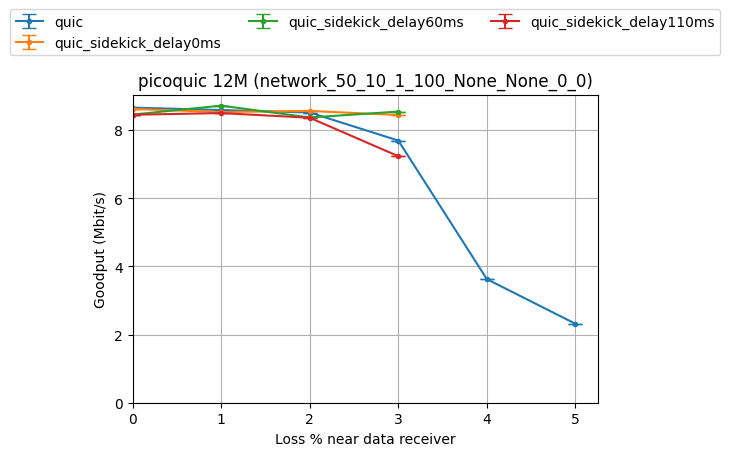

In [67]:
def plot_loss_vs_throughput(prefix, raw_data):
    title = f'{prefix} {data_size_str(DATA_SIZES[0])} ({NETWORK_SETTINGS()[0].label()})'
    ylabel = 'Goodput (Mbit/s)'
    plottable_data = PlottableData(raw_data, 'throughput_mbps')
    plot_loss_vs_metric_line(plottable_data, title=title, ylabel=ylabel)

plot_loss_vs_throughput('picoquic', picoquic_raw_data)
# plot_loss_vs_throughput('tcp', tcp_raw_data)
# plot_loss_vs_throughput('chromium', chromium_raw_data)

In [68]:
def plot_loss_vs_num_spurious(prefix, raw_data, sender: bool):
    key = 'Sender' if sender else 'Receiver'
    def num_spurious_func(output):
        if 'additional_data' not in output:
            return 0
        data_key = f'num_spurious_{key.lower()}'
        if data_key not in output['additional_data']:
            print(output['additional_data'])
        return output['additional_data'][data_key]
    
    title = f'{prefix} {data_size_str(DATA_SIZES[0])} ({NETWORK_SETTINGS()[0].label()})'
    plottable_data = PlottableData(raw_data, num_spurious_func)
    plot_loss_vs_metric_line(plottable_data, title=title, ylabel=f'Num Spurious Retransmissions ({key})')

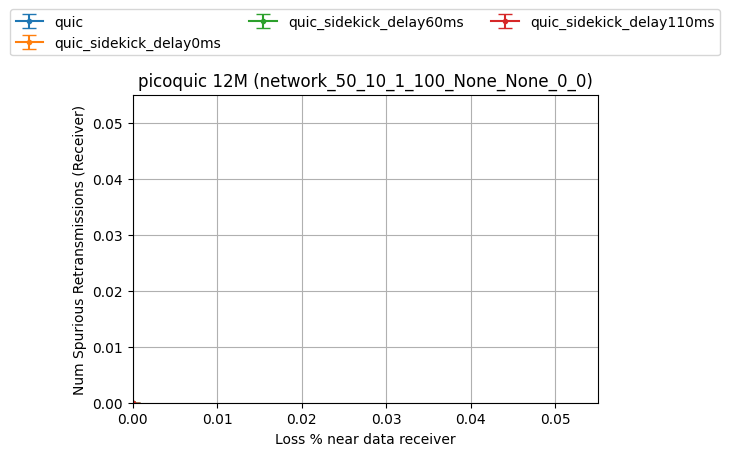

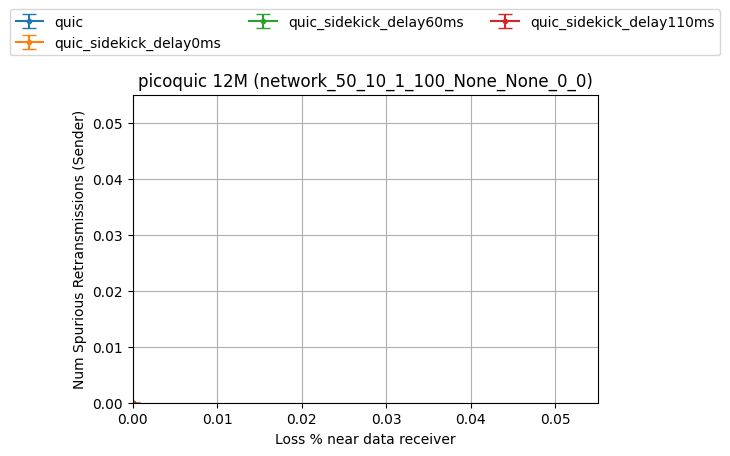

In [59]:
plot_loss_vs_num_spurious('picoquic', picoquic_raw_data, sender=False)
plot_loss_vs_num_spurious('picoquic', picoquic_raw_data, sender=True)

In [60]:
def plot_loss_vs_network_metric(prefix, raw_data, metric):
    def metric_func(iface, metric):
        def func(output):
            statistics = output['statistics']
            iface_index = statistics['ifaces'].index(iface)
            return statistics[metric][iface_index]
        return func

    for iface in ['h1-eth0', 'p1-eth1', 'h2-eth0', 'p1-eth0']:
        title = f'{prefix} {data_size_str(DATA_SIZES[0])} ({NETWORK_SETTINGS()[0].label()})'
        ylabel = f'{iface} {metric}'
        plottable_data = PlottableData(raw_data, metric_func(iface, metric))
        plot_loss_vs_metric_line(plottable_data, title=title, ylabel=ylabel)

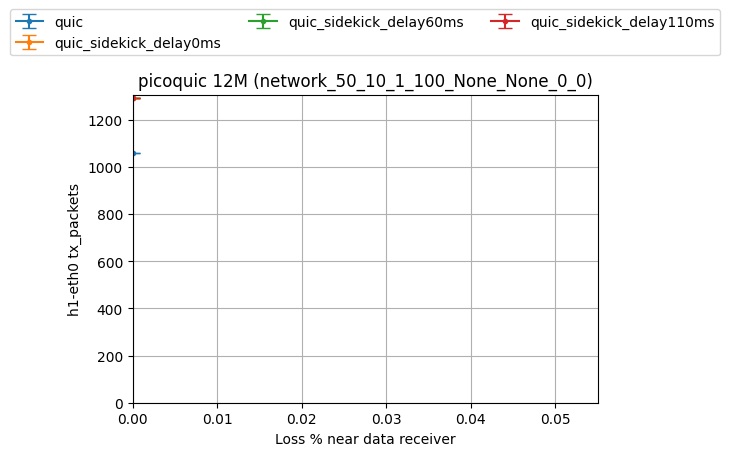

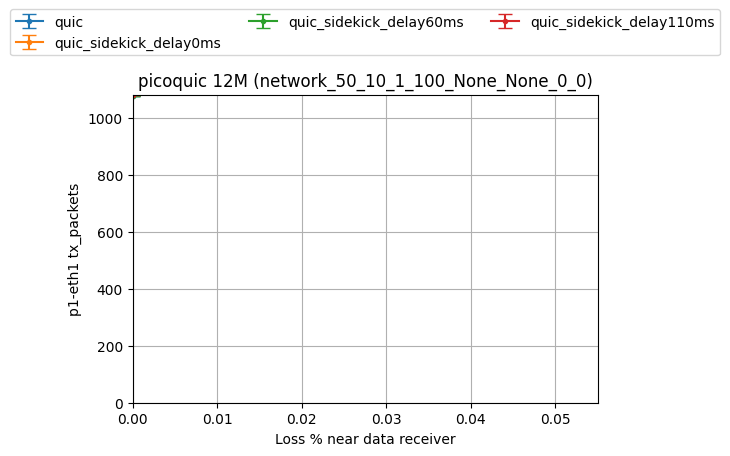

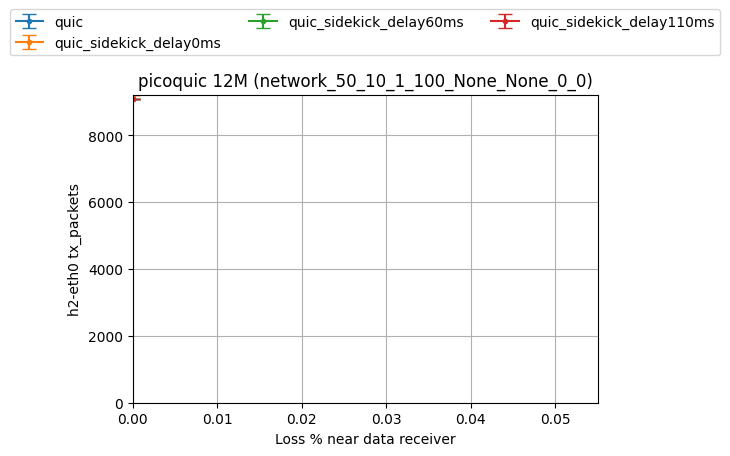

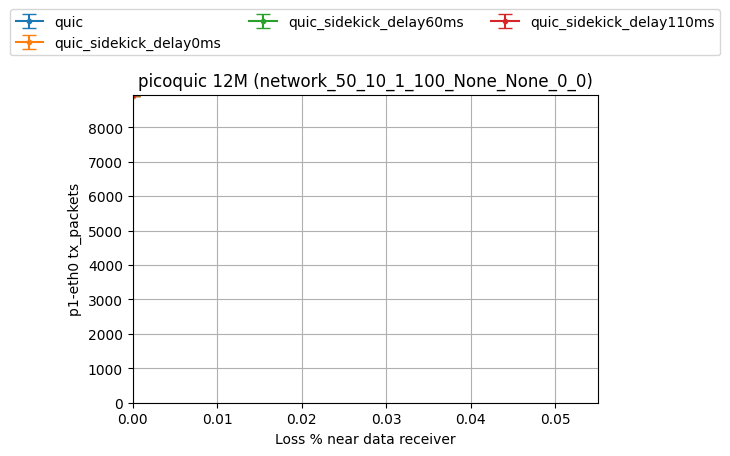

In [61]:
plot_loss_vs_network_metric('picoquic', picoquic_raw_data, 'tx_packets')

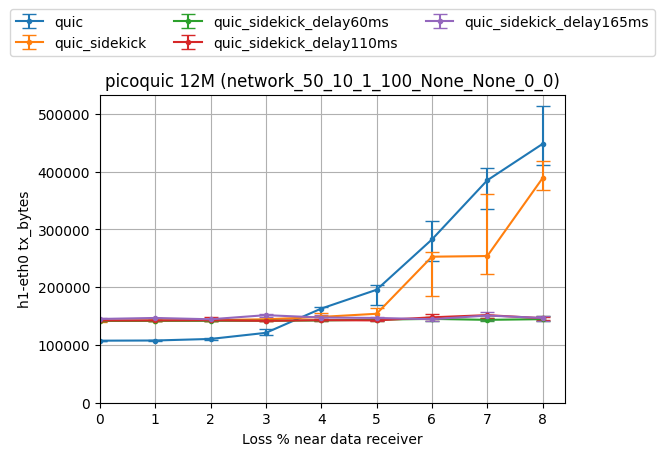

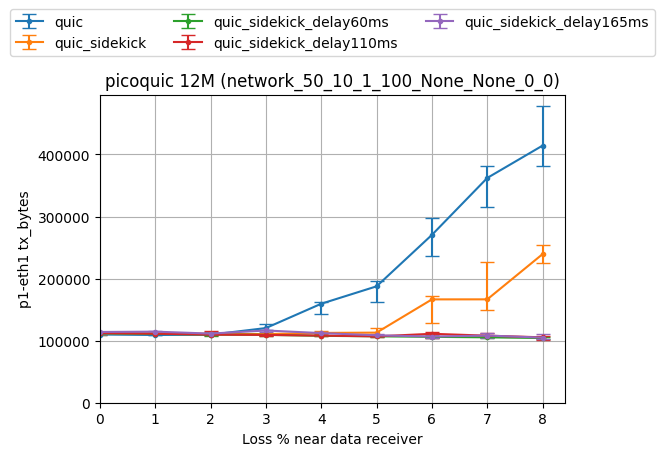

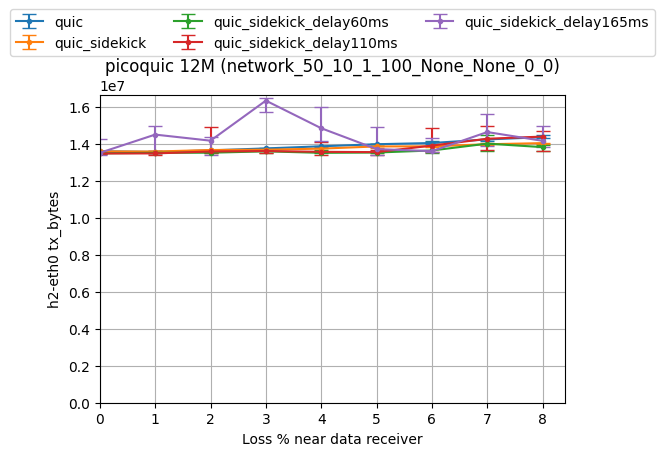

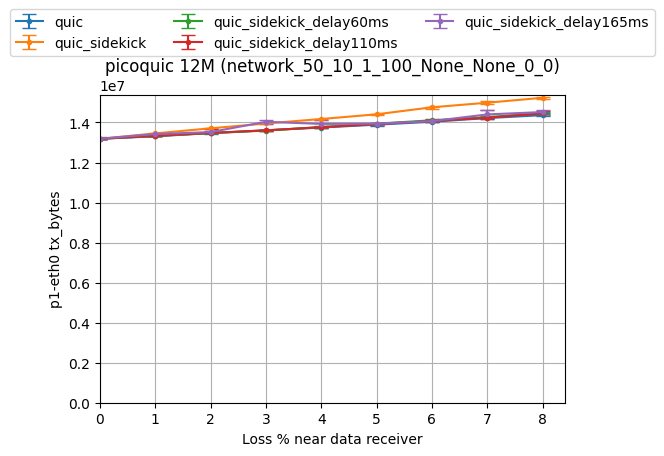

In [50]:
plot_loss_vs_network_metric('picoquic', picoquic_raw_data, 'tx_bytes')